In [ ]:
!pip install pydub pandas
!apt-get update -y && apt-get install -y ffmpeg

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,078 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,319 kB]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Package

In [ ]:
import os
from google.colab import files

BASE_DIR = "/content/finalprojectwakeword"
WAKE_DIR = os.path.join(BASE_DIR, "dataset", "wakeword")
NONWAKE_DIR = os.path.join(BASE_DIR, "dataset", "nonwakeword")

os.makedirs(WAKE_DIR, exist_ok=True)
os.makedirs(NONWAKE_DIR, exist_ok=True)

print("Folder siap:")
print(WAKE_DIR)
print(NONWAKE_DIR)

Folder siap:
/content/finalprojectwakeword/dataset/wakeword
/content/finalprojectwakeword/dataset/nonwakeword


In [ ]:
uploaded_wake = files.upload()

for filename, data in uploaded_wake.items():
    save_path = os.path.join(WAKE_DIR, filename)
    with open(save_path, "wb") as f:
        f.write(data)

print("File wakeword tersimpan di:", WAKE_DIR)
print(os.listdir(WAKE_DIR))

Saving hello keyword.m4a to hello keyword.m4a
File wakeword tersimpan di: /content/finalprojectwakeword/dataset/wakeword
['hello keyword.m4a']


In [ ]:
uploaded_nonwake = files.upload()

for filename, data in uploaded_nonwake.items():
    save_path = os.path.join(NONWAKE_DIR, filename)
    with open(save_path, "wb") as f:
        f.write(data)

print("File nonwakeword tersimpan di:", NONWAKE_DIR)
print(os.listdir(NONWAKE_DIR))

Saving record no word 2.m4a to record no word 2.m4a
File nonwakeword tersimpan di: /content/finalprojectwakeword/dataset/nonwakeword
['record no word 2.m4a']


In [ ]:
import glob
import pandas as pd
from pydub import AudioSegment
from pydub.silence import detect_nonsilent

OUT_WAKE_DIR = os.path.join(BASE_DIR, "dataset", "wakeword_wav")
OUT_NONWAKE_DIR = os.path.join(BASE_DIR, "dataset", "nonwakeword_wav")
ANNOT_PATH = os.path.join(BASE_DIR, "dataset", "annotations.csv")

os.makedirs(OUT_WAKE_DIR, exist_ok=True)
os.makedirs(OUT_NONWAKE_DIR, exist_ok=True)

SPEAKER_DEFAULT = "speaker_1"
ENV_DEFAULT = "indoor"

MIN_SILENCE_LEN = 300
SILENCE_THRESH_OFFSET = 16
KEEP_PADDING_MS = 150
MIN_SEGMENT_MS = 250
MAX_SEGMENT_MS = 2000

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
def convert_to_wav_16k_mono(src_path, dst_path):
    audio = AudioSegment.from_file(src_path)
    audio = audio.set_frame_rate(16000).set_channels(1).set_sample_width(2)
    audio.export(dst_path, format="wav")
    return dst_path

def normalize_audio(audio, target_dbfs=-20.0):
    if audio.dBFS == float("-inf"):
        return audio
    gain = target_dbfs - audio.dBFS
    return audio.apply_gain(gain)

def detect_segments(audio):
    audio = normalize_audio(audio)
    silence_thresh = audio.dBFS - SILENCE_THRESH_OFFSET

    segments = detect_nonsilent(
        audio,
        min_silence_len=MIN_SILENCE_LEN,
        silence_thresh=silence_thresh,
        seek_step=1
    )

    cleaned = []
    for start_ms, end_ms in segments:
        start_ms = max(0, start_ms - KEEP_PADDING_MS)
        end_ms = min(len(audio), end_ms + KEEP_PADDING_MS)
        duration = end_ms - start_ms

        if duration < MIN_SEGMENT_MS:
            continue
        if duration > MAX_SEGMENT_MS:
            continue

        cleaned.append((start_ms, end_ms))

    return cleaned

In [ ]:
rows = []

wake_files = []
for ext in ["*.wav", "*.mp3", "*.m4a", "*.flac", "*.ogg"]:
    wake_files.extend(glob.glob(os.path.join(WAKE_DIR, ext)))

for src_path in sorted(wake_files):
    out_name = os.path.splitext(os.path.basename(src_path))[0] + ".wav"
    dst_path = os.path.join(OUT_WAKE_DIR, out_name)

    convert_to_wav_16k_mono(src_path, dst_path)
    audio = AudioSegment.from_wav(dst_path)
    segments = detect_segments(audio)

    if len(segments) == 0:
        rows.append({
            "filename": out_name,
            "start_time": "",
            "end_time": "",
            "label": "wake_word",
            "speaker": SPEAKER_DEFAULT,
            "environment": ENV_DEFAULT
        })
    else:
        for start_ms, end_ms in segments:
            rows.append({
                "filename": out_name,
                "start_time": round(start_ms / 1000, 2),
                "end_time": round(end_ms / 1000, 2),
                "label": "wake_word",
                "speaker": SPEAKER_DEFAULT,
                "environment": ENV_DEFAULT
            })

In [ ]:
nonwake_files = []
for ext in ["*.wav", "*.mp3", "*.m4a", "*.flac", "*.ogg"]:
    nonwake_files.extend(glob.glob(os.path.join(NONWAKE_DIR, ext)))

for src_path in sorted(nonwake_files):
    out_name = os.path.splitext(os.path.basename(src_path))[0] + ".wav"
    dst_path = os.path.join(OUT_NONWAKE_DIR, out_name)

    convert_to_wav_16k_mono(src_path, dst_path)

    rows.append({
        "filename": out_name,
        "start_time": "",
        "end_time": "",
        "label": "non_wake_word",
        "speaker": SPEAKER_DEFAULT,
        "environment": ENV_DEFAULT
    })

In [ ]:
df = pd.DataFrame(rows, columns=[
    "filename", "start_time", "end_time", "label", "speaker", "environment"
])

df.to_csv(ANNOT_PATH, index=False, encoding="utf-8")

print("annotations.csv berhasil dibuat di:")
print(ANNOT_PATH)
display(df.head(20))
print("Total baris:", len(df))

annotations.csv berhasil dibuat di:
/content/finalprojectwakeword/dataset/annotations.csv


,filename,start_time,end_time,label,speaker,environment
0,hello keyword.wav,4.98,5.33,wake_word,speaker_1,indoor
1,hello keyword.wav,9.95,10.88,wake_word,speaker_1,indoor
2,hello keyword.wav,34.57,35.47,wake_word,speaker_1,indoor
3,hello keyword.wav,42.95,43.32,wake_word,speaker_1,indoor
4,hello keyword.wav,49.03,50.01,wake_word,speaker_1,indoor
5,hello keyword.wav,63.68,64.63,wake_word,speaker_1,indoor
6,hello keyword.wav,72.71,73.69,wake_word,speaker_1,indoor
7,hello keyword.wav,82.6,83.62,wake_word,speaker_1,indoor
8,hello keyword.wav,99.83,100.91,wake_word,speaker_1,indoor
9,hello keyword.wav,115.15,116.3,wake_word,speaker_1,indoor


Total baris: 443


In [ ]:
!pip install hmmlearn librosa soundfile scikit-learn pandas numpy matplotlib seaborn joblib pydub
!apt-get update -y && apt-get install -y ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.8 MB/s eta 0:00:00
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is alre

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd

BASE_DIR = "/content/finalprojectwakeword"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
WAKE_WAV_DIR = os.path.join(DATASET_DIR, "wakeword_wav")
NONWAKE_WAV_DIR = os.path.join(DATASET_DIR, "nonwakeword_wav")
ANNOT_PATH = os.path.join(DATASET_DIR, "annotations.csv")

N_MFCC = 13
N_FFT = 400
HOP_LENGTH = 160
WIN_LENGTH = 400

ann = pd.read_csv(ANNOT_PATH)
ann.head()

,filename,start_time,end_time,label,speaker,environment
0,hello keyword.wav,4.98,5.33,wake_word,speaker_1,indoor
1,hello keyword.wav,9.95,10.88,wake_word,speaker_1,indoor
2,hello keyword.wav,34.57,35.47,wake_word,speaker_1,indoor
3,hello keyword.wav,42.95,43.32,wake_word,speaker_1,indoor
4,hello keyword.wav,49.03,50.01,wake_word,speaker_1,indoor


In [ ]:
def extract_mfcc_segment(audio_path, start_time=None, end_time=None, sr=16000):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    if pd.notna(start_time) and pd.notna(end_time):
        start_sample = int(float(start_time) * sr)
        end_sample = int(float(end_time) * sr)
        y = y[start_sample:end_sample]

    if len(y) < 400:
        return None

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    ).T

    return mfcc

In [ ]:
def extract_mfcc_chunks(audio_path, sr=16000, chunk_sec=1.0):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)
    chunk_len = int(chunk_sec * sr)
    chunks = []

    for start in range(0, len(y), chunk_len):
        seg = y[start:start + chunk_len]
        if len(seg) < int(0.5 * chunk_len):
            continue

        mfcc = librosa.feature.mfcc(
            y=seg,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH
        ).T

        if len(mfcc) > 0:
            chunks.append(mfcc)

    return chunks

In [ ]:
samples = []

for _, row in ann.iterrows():
    filename = row["filename"]
    label = row["label"]

    if label == "wake_word":
        audio_path = os.path.join(WAKE_WAV_DIR, filename)
        if not os.path.exists(audio_path):
            continue

        mfcc = extract_mfcc_segment(audio_path, row["start_time"], row["end_time"])
        if mfcc is None:
            continue

        samples.append({
            "filename": filename,
            "label": label,
            "mfcc": mfcc,
            "length": len(mfcc)
        })

    else:
        audio_path = os.path.join(NONWAKE_WAV_DIR, filename)
        if not os.path.exists(audio_path):
            continue

        mfcc_chunks = extract_mfcc_chunks(audio_path, sr=16000, chunk_sec=1.0)
        for i, mfcc in enumerate(mfcc_chunks):
            samples.append({
                "filename": f"{filename}_chunk{i}",
                "label": label,
                "mfcc": mfcc,
                "length": len(mfcc)
            })

print(pd.DataFrame(samples)["label"].value_counts())

label
non_wake_word    4161
wake_word         442
Name: count, dtype: int64


In [ ]:
def extract_mfcc_chunks(audio_path, sr=16000, chunk_sec=1.0):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)
    chunk_len = int(chunk_sec * sr)
    chunks = []

    for start in range(0, len(y), chunk_len):
        seg = y[start:start + chunk_len]
        if len(seg) < int(0.5 * chunk_len):
            continue

        mfcc = librosa.feature.mfcc(
            y=seg,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH
        ).T

        if len(mfcc) > 0:
            chunks.append(mfcc)

    return chunks


samples = []

for _, row in ann.iterrows():
    filename = row["filename"]
    label = row["label"]

    if label == "wake_word":
        audio_path = os.path.join(WAKE_WAV_DIR, filename)
        if not os.path.exists(audio_path):
            continue

        mfcc = extract_mfcc_segment(audio_path, row["start_time"], row["end_time"])
        if mfcc is None:
            continue

        samples.append({
            "filename": filename,
            "label": label,
            "mfcc": mfcc,
            "length": len(mfcc)
        })

    else:
        audio_path = os.path.join(NONWAKE_WAV_DIR, filename)
        if not os.path.exists(audio_path):
            continue

        mfcc_chunks = extract_mfcc_chunks(audio_path, sr=16000, chunk_sec=1.0)
        for i, mfcc in enumerate(mfcc_chunks):
            samples.append({
                "filename": f"{filename}_chunk{i}",
                "label": label,
                "mfcc": mfcc,
                "length": len(mfcc)
            })

print(pd.DataFrame(samples)["label"].value_counts())

label
non_wake_word    4161
wake_word         442
Name: count, dtype: int64


In [ ]:
df_samples = pd.DataFrame(samples)

wake_df = df_samples[df_samples["label"] == "wake_word"]
nonwake_df = df_samples[df_samples["label"] == "non_wake_word"].sample(
    n=len(wake_df),
    random_state=42
)

df_samples = pd.concat([wake_df, nonwake_df]).sample(frac=1, random_state=42).reset_index(drop=True)
df_samples["y"] = df_samples["label"].map({"wake_word": 1, "non_wake_word": 0})

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_samples,
    test_size=0.30,
    stratify=df_samples["y"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["y"],
    random_state=42
)

print("TRAIN")
print(train_df["label"].value_counts())
print("VAL")
print(val_df["label"].value_counts())
print("TEST")
print(test_df["label"].value_counts())

TRAIN
label
non_wake_word    309
wake_word        309
Name: count, dtype: int64
VAL
label
wake_word        67
non_wake_word    66
Name: count, dtype: int64
TEST
label
non_wake_word    67
wake_word        66
Name: count, dtype: int64


#Training

In [ ]:
def stack_sequences(df):
    X_list = df["mfcc"].tolist()
    lengths = [x.shape[0] for x in X_list]
    X = np.vstack(X_list)
    return X, lengths

wake_train = train_df[train_df["label"] == "wake_word"]
nonwake_train = train_df[train_df["label"] == "non_wake_word"]

X_wake, lengths_wake = stack_sequences(wake_train)
X_nonwake, lengths_nonwake = stack_sequences(nonwake_train)

print("Wake train:", X_wake.shape, len(lengths_wake))
print("Nonwake train:", X_nonwake.shape, len(lengths_nonwake))

Wake train: (29018, 13) 309
Nonwake train: (31209, 13) 309


In [ ]:
from hmmlearn.hmm import GMMHMM

N_STATES = 3
N_MIX = 2
RANDOM_STATE = 42

wake_model = GMMHMM(
    n_components=N_STATES,
    n_mix=N_MIX,
    covariance_type="diag",
    n_iter=100,
    random_state=RANDOM_STATE,
    verbose=True
)

nonwake_model = GMMHMM(
    n_components=N_STATES,
    n_mix=N_MIX,
    covariance_type="diag",
    n_iter=100,
    random_state=RANDOM_STATE,
    verbose=True
)

wake_model.fit(X_wake, lengths_wake)
nonwake_model.fit(X_nonwake, lengths_nonwake)
print("Training selesai")

         1 -1686932.04546616             +nan
         2 -1544210.19310174 +142721.85236442
         3 -1464529.61718930  +79680.57591244
         4 -1440782.23121075  +23747.38597855
         5 -1437457.32891034   +3324.90230041
         6 -1436414.66677640   +1042.66213394
         7 -1435837.65512241    +577.01165399
         8 -1435587.57589514    +250.07922727
         9 -1435304.32787613    +283.24801901
        10 -1435228.23390556     +76.09397058
        11 -1435213.79886208     +14.43504347
        12 -1435208.51761402      +5.28124807
        13 -1435206.96597195      +1.55164206
        14 -1435206.49799293      +0.46797902
        15 -1435206.31304560      +0.18494733
        16 -1435206.22992934      +0.08311626
        17 -1435206.19088561      +0.03904373
        18 -1435206.17210759      +0.01877802
        19 -1435206.16289229      +0.00921531
         1 -1714385.16057448             +nan
         2 -1674401.50174963  +39983.65882485
         3 -1658469.72595555  +159

Training selesai


       100 -1638802.72467002      +0.05013076


#Threshold

In [ ]:
def score_models(mfcc):
    wake_score = wake_model.score(mfcc)
    nonwake_score = nonwake_model.score(mfcc)
    llr = wake_score - nonwake_score
    return wake_score, nonwake_score, llr

def predict_with_threshold(mfcc, threshold=0.0):
    wake_score, nonwake_score, llr = score_models(mfcc)
    pred = 1 if llr >= threshold else 0
    return pred, wake_score, nonwake_score, llr

In [ ]:
import os

BASE_DIR = "/content/finalprojectwakeword"
RESULT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

print(RESULT_DIR)

/content/finalprojectwakeword/results


In [ ]:
val_scores = []

for _, row in val_df.iterrows():
    pred0, wake_score, nonwake_score, llr = predict_with_threshold(row["mfcc"], threshold=0.0)
    val_scores.append({
        "y_true": row["y"],
        "wake_score": wake_score,
        "nonwake_score": nonwake_score,
        "llr": llr
    })

val_scores = pd.DataFrame(val_scores)

threshold_candidates = np.linspace(val_scores["llr"].min(), val_scores["llr"].max(), 50)

best_threshold = 0
best_f1 = -1
threshold_rows = []

for th in threshold_candidates:
    y_pred = (val_scores["llr"] >= th).astype(int)
    y_true = val_scores["y_true"].values

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    far = fp / max(fp + tn, 1)
    frr = fn / max(fn + tp, 1)

    threshold_rows.append([th, acc, prec, rec, f1, far, frr])

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

threshold_df = pd.DataFrame(
    threshold_rows,
    columns=["threshold", "accuracy", "precision", "recall", "f1", "far", "frr"]
)

threshold_df.to_csv(os.path.join(RESULT_DIR, "threshold_analysis.csv"), index=False)

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)
threshold_df.sort_values("f1", ascending=False).head(10)

Best threshold: -144.64329094827986
Best validation F1: 0.9781021897810218


,threshold,accuracy,precision,recall,f1,far,frr
13,-144.643291,0.977444,0.957143,1.000000,0.978102,0.045455,0.000000
12,-268.816098,0.969925,0.943662,1.000000,0.971014,0.060606,0.000000
11,-392.988905,0.962406,0.930556,1.000000,0.964029,0.075758,0.000000
14,-20.470484,0.962406,0.969697,0.955224,0.962406,0.030303,0.044776
15,103.702323,0.962406,0.984375,0.940299,0.961832,0.015152,0.059701
16,227.875130,0.962406,0.984375,0.940299,0.961832,0.015152,0.059701
10,-517.161712,0.939850,0.893333,1.000000,0.943662,0.121212,0.000000
17,352.047937,0.939850,0.983607,0.895522,0.937500,0.015152,0.104478
9,-641.334519,0.894737,0.827160,1.000000,0.905405,0.212121,0.000000
18,476.220744,0.909774,0.982456,0.835821,0.903226,0.015152,0.164179


#Evaluasi test

In [ ]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []
test_rows = []

for _, row in test_df.iterrows():
    pred, wake_score, nonwake_score, llr = predict_with_threshold(row["mfcc"], threshold=best_threshold)
    y_true.append(row["y"])
    y_pred.append(pred)

    test_rows.append({
        "filename": row["filename"],
        "true_label": row["label"],
        "pred_label": "wake_word" if pred == 1 else "non_wake_word",
        "wake_score": wake_score,
        "nonwake_score": nonwake_score,
        "llr": llr
    })

test_result_df = pd.DataFrame(test_rows)
test_result_df.to_csv(os.path.join(RESULT_DIR, "test_predictions.csv"), index=False)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[66  1]
 [ 0 66]]


In [ ]:
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-9)
far = fp / max(fp + tn, 1)
frr = fn / max(fn + tp, 1)

metrics_df = pd.DataFrame([{
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "far": far,
    "frr": frr,
    "best_threshold": best_threshold
}])

metrics_df.to_csv(os.path.join(RESULT_DIR, "evaluation_metrics.csv"), index=False)
metrics_df

,accuracy,precision,recall,f1_score,far,frr,best_threshold
0,0.992481,0.985075,1.0,0.992481,0.014925,0.0,-144.643291


#Simpan confusion matrix

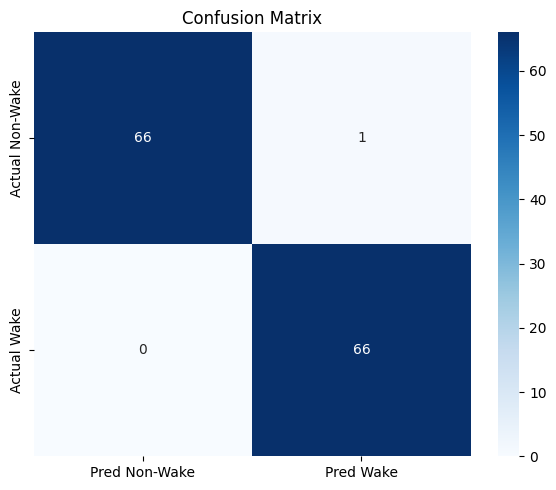

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Non-Wake", "Pred Wake"],
    yticklabels=["Actual Non-Wake", "Actual Wake"]
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

#Simpan model

In [ ]:
import os
import joblib

BASE_DIR = "/content/finalprojectwakeword"
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

print(MODEL_DIR)

/content/finalprojectwakeword/models


In [ ]:
import joblib

joblib.dump(wake_model, os.path.join(MODEL_DIR, "wake_model.pkl"))
joblib.dump(nonwake_model, os.path.join(MODEL_DIR, "nonwake_model.pkl"))
joblib.dump(best_threshold, os.path.join(MODEL_DIR, "best_threshold.pkl"))

print("Model tersimpan")

Model tersimpan


#Demo file baru

In [ ]:
from google.colab import files
from pydub import AudioSegment

uploaded_test = files.upload()

def convert_test_audio_to_wav(src_path, dst_path):
    audio = AudioSegment.from_file(src_path)
    audio = audio.set_frame_rate(16000).set_channels(1).set_sample_width(2)
    audio.export(dst_path, format="wav")

for filename in uploaded_test.keys():
    src_path = f"/content/{filename}"
    wav_path = "/content/test_input.wav"

    convert_test_audio_to_wav(src_path, wav_path)
    mfcc_chunks = extract_mfcc_chunks(wav_path, sr=16000, chunk_sec=1.0)

    chunk_preds = []
    for mfcc in mfcc_chunks:
        pred, wake_score, nonwake_score, llr = predict_with_threshold(mfcc, threshold=best_threshold)
        chunk_preds.append(pred)

    final_pred = 1 if sum(chunk_preds) > 0 else 0

    print("File:", filename)
    print("Prediction:", "wake_word" if final_pred == 1 else "non_wake_word")
    print("Jumlah chunk:", len(chunk_preds))
    print("Chunk wake count:", sum(chunk_preds))

Saving hello activate.m4a to hello activate.m4a
Saving sekarang jam berapa.m4a to sekarang jam berapa.m4a
File: hello activate.m4a
Prediction: wake_word
Jumlah chunk: 6
Chunk wake count: 2
File: sekarang jam berapa.m4a
Prediction: wake_word
Jumlah chunk: 4
Chunk wake count: 4


#preprocess_audio.py

In [ ]:
import os

PROJECT_DIR = "/content/final_project_wake_word"
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
PREPROCESS_DIR = os.path.join(PROJECT_DIR, "preprocessing")
FEATURES_DIR = os.path.join(PROJECT_DIR, "features")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
EVAL_DIR = os.path.join(PROJECT_DIR, "evaluation")
DEMO_DIR = os.path.join(PROJECT_DIR, "demo")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

for d in [PROJECT_DIR, PREPROCESS_DIR, FEATURES_DIR, MODELS_DIR, EVAL_DIR, DEMO_DIR, RESULTS_DIR, DATASET_DIR]:
    os.makedirs(d, exist_ok=True)

print("Folder project berhasil dibuat")
print(os.listdir(PROJECT_DIR))

Folder project berhasil dibuat
['dataset', 'preprocessing', 'evaluation', 'features', 'demo', 'results', 'models']


In [ ]:
import os
from pydub import AudioSegment
from pydub.effects import normalize

BASE_DIR = "/content/finalprojectwakeword"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")

WAKE_DIR = os.path.join(DATASET_DIR, "wakeword")
NONWAKE_DIR = os.path.join(DATASET_DIR, "nonwakeword")

WAKE_WAV_DIR = os.path.join(DATASET_DIR, "wakeword_wav")
NONWAKE_WAV_DIR = os.path.join(DATASET_DIR, "nonwakeword_wav")

for d in [WAKE_WAV_DIR, NONWAKE_WAV_DIR]:
    os.makedirs(d, exist_ok=True)

def convert_to_wav(input_path, output_path):
    audio = AudioSegment.from_file(input_path)
    audio = normalize(audio)
    audio = audio.set_frame_rate(16000).set_channels(1).set_sample_width(2)
    audio.export(output_path, format="wav")

def batch_convert(input_dir, output_dir):
    for fname in os.listdir(input_dir):
        in_path = os.path.join(input_dir, fname)
        if not os.path.isfile(in_path):
            continue

        out_name = os.path.splitext(fname)[0] + ".wav"
        out_path = os.path.join(output_dir, out_name)

        convert_to_wav(in_path, out_path)
        print(f"Converted: {fname} -> {out_name}")

batch_convert(WAKE_DIR, WAKE_WAV_DIR)
batch_convert(NONWAKE_DIR, NONWAKE_WAV_DIR)
print("Preprocessing selesai")

Converted: hello keyword.m4a -> hello keyword.wav
Converted: record no word 2.m4a -> record no word 2.wav
Preprocessing selesai


In [ ]:
import os

PROJECT_DIR = "/content/final_project_wake_word"

folders = [
    PROJECT_DIR,
    os.path.join(PROJECT_DIR, "dataset"),
    os.path.join(PROJECT_DIR, "preprocessing"),
    os.path.join(PROJECT_DIR, "features"),
    os.path.join(PROJECT_DIR, "models"),
    os.path.join(PROJECT_DIR, "evaluation"),
    os.path.join(PROJECT_DIR, "demo"),
    os.path.join(PROJECT_DIR, "results"),
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Struktur folder berhasil dibuat:")
for folder in folders:
    print(folder)

Struktur folder berhasil dibuat:
/content/final_project_wake_word
/content/final_project_wake_word/dataset
/content/final_project_wake_word/preprocessing
/content/final_project_wake_word/features
/content/final_project_wake_word/models
/content/final_project_wake_word/evaluation
/content/final_project_wake_word/demo
/content/final_project_wake_word/results


In [ ]:
import os

PROJECT_DIR = "/content/final_project_wake_word"

preprocess_code = r'''
import os
from pydub import AudioSegment
from pydub.effects import normalize

BASE_DIR = "/content/final_project_wake_word"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")

WAKE_DIR = os.path.join(DATASET_DIR, "wakeword")
NONWAKE_DIR = os.path.join(DATASET_DIR, "nonwakeword")

WAKE_WAV_DIR = os.path.join(DATASET_DIR, "wakeword_wav")
NONWAKE_WAV_DIR = os.path.join(DATASET_DIR, "nonwakeword_wav")

for d in [WAKE_WAV_DIR, NONWAKE_WAV_DIR]:
    os.makedirs(d, exist_ok=True)

def convert_to_wav(input_path, output_path):
    audio = AudioSegment.from_file(input_path)
    audio = normalize(audio)
    audio = audio.set_frame_rate(16000).set_channels(1).set_sample_width(2)
    audio.export(output_path, format="wav")

def batch_convert(input_dir, output_dir):
    for fname in os.listdir(input_dir):
        in_path = os.path.join(input_dir, fname)
        if not os.path.isfile(in_path):
            continue

        out_name = os.path.splitext(fname)[0] + ".wav"
        out_path = os.path.join(output_dir, out_name)

        convert_to_wav(in_path, out_path)
        print(f"Converted: {fname} -> {out_name}")

if __name__ == "__main__":
    batch_convert(WAKE_DIR, WAKE_WAV_DIR)
    batch_convert(NONWAKE_DIR, NONWAKE_WAV_DIR)
    print("Preprocessing selesai")
'''

mfcc_code = r'''
import librosa
import numpy as np

SR = 16000
N_MFCC = 13
N_FFT = 400
HOP_LENGTH = 160
WIN_LENGTH = 400

def extract_mfcc_segment(audio_path, start_time, end_time, sr=SR):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    if start_time is None or end_time is None:
        return None
    if np.isnan(start_time) or np.isnan(end_time):
        return None

    start_sample = int(start_time * sr)
    end_sample = int(end_time * sr)
    segment = y[start_sample:end_sample]

    if len(segment) == 0:
        return None

    mfcc = librosa.feature.mfcc(
        y=segment,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    ).T

    return mfcc if len(mfcc) > 0 else None

def extract_mfcc_chunks(audio_path, sr=SR, chunk_sec=1.0):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)
    chunk_len = int(chunk_sec * sr)
    chunks = []

    for start in range(0, len(y), chunk_len):
        seg = y[start:start + chunk_len]

        if len(seg) < int(0.5 * chunk_len):
            continue

        mfcc = librosa.feature.mfcc(
            y=seg,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH
        ).T

        if len(mfcc) > 0:
            chunks.append(mfcc)

    return chunks
'''

os.makedirs(os.path.join(PROJECT_DIR, "preprocessing"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "features"), exist_ok=True)

with open(os.path.join(PROJECT_DIR, "preprocessing", "preprocess_audio.py"), "w") as f:
    f.write(preprocess_code.strip() + "\n")

with open(os.path.join(PROJECT_DIR, "features", "extract_mfcc.py"), "w") as f:
    f.write(mfcc_code.strip() + "\n")

print("Berhasil membuat:")
print(os.path.join(PROJECT_DIR, "preprocessing", "preprocess_audio.py"))
print(os.path.join(PROJECT_DIR, "features", "extract_mfcc.py"))

Berhasil membuat:
/content/final_project_wake_word/preprocessing/preprocess_audio.py
/content/final_project_wake_word/features/extract_mfcc.py


In [45]:
import os

PROJECT_DIR = "/content/final_project_wake_word"

print("preprocessing:", os.listdir(os.path.join(PROJECT_DIR, "preprocessing")))
print("features:", os.listdir(os.path.join(PROJECT_DIR, "features")))

preprocessing: ['preprocess_audio.py']
features: ['extract_mfcc.py']


In [46]:
import os

PROJECT_DIR = "/content/final_project_wake_word"

train_code = r'''
import os
import sys
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from hmmlearn.hmm import GMMHMM

BASE_DIR = "/content/final_project_wake_word"
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from features.extract_mfcc import extract_mfcc_segment, extract_mfcc_chunks

DATASET_DIR = os.path.join(BASE_DIR, "dataset")
MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULT_DIR = os.path.join(BASE_DIR, "results")

WAKE_WAV_DIR = os.path.join(DATASET_DIR, "wakeword_wav")
NONWAKE_WAV_DIR = os.path.join(DATASET_DIR, "nonwakeword_wav")
ANNOTATION_PATH = os.path.join(DATASET_DIR, "annotations.csv")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

WAKE_LABELS = ["wake_word", "wakeword"]
NONWAKE_LABELS = ["non_wake_word", "nonwakeword"]

def normalize_label(label):
    label = str(label).strip().lower()
    if label in WAKE_LABELS:
        return "wake_word"
    if label in NONWAKE_LABELS:
        return "non_wake_word"
    return label

def stack_sequences(df):
    x_list = df["mfcc"].tolist()
    lengths = [x.shape[0] for x in x_list]
    X = np.vstack(x_list)
    return X, lengths

def score_models(mfcc, wake_model, nonwake_model):
    wake_score = wake_model.score(mfcc)
    nonwake_score = nonwake_model.score(mfcc)
    llr = wake_score - nonwake_score
    return wake_score, nonwake_score, llr

def predict_with_threshold(mfcc, wake_model, nonwake_model, threshold):
    wake_score, nonwake_score, llr = score_models(mfcc, wake_model, nonwake_model)
    pred = 1 if llr >= threshold else 0
    return pred, wake_score, nonwake_score, llr

ann = pd.read_csv(ANNOTATION_PATH)
ann["label"] = ann["label"].apply(normalize_label)

samples = []
for _, row in ann.iterrows():
    filename = row["filename"]
    label = row["label"]

    if label == "wake_word":
        audio_path = os.path.join(WAKE_WAV_DIR, filename)
        if not os.path.exists(audio_path):
            continue

        mfcc = extract_mfcc_segment(audio_path, row["start_time"], row["end_time"])
        if mfcc is None:
            continue

        samples.append({
            "filename": filename,
            "label": label,
            "mfcc": mfcc,
            "length": len(mfcc)
        })

    else:
        audio_path = os.path.join(NONWAKE_WAV_DIR, filename)
        if not os.path.exists(audio_path):
            continue

        mfcc_chunks = extract_mfcc_chunks(audio_path, sr=16000, chunk_sec=1.0)
        for i, mfcc in enumerate(mfcc_chunks):
            samples.append({
                "filename": f"{filename}_chunk{i}",
                "label": label,
                "mfcc": mfcc,
                "length": len(mfcc)
            })

df_samples = pd.DataFrame(samples)

wake_df = df_samples[df_samples["label"] == "wake_word"]
nonwake_df = df_samples[df_samples["label"] == "non_wake_word"].sample(
    n=len(wake_df),
    random_state=42
)

df_samples = pd.concat([wake_df, nonwake_df]).sample(frac=1, random_state=42).reset_index(drop=True)
df_samples["y"] = df_samples["label"].map({"wake_word": 1, "non_wake_word": 0})

train_df, temp_df = train_test_split(
    df_samples,
    test_size=0.30,
    stratify=df_samples["y"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["y"],
    random_state=42
)

wake_train = train_df[train_df["y"] == 1]
nonwake_train = train_df[train_df["y"] == 0]

X_wake, lengths_wake = stack_sequences(wake_train)
X_nonwake, lengths_nonwake = stack_sequences(nonwake_train)

wake_model = GMMHMM(
    n_components=4,
    n_mix=2,
    covariance_type="diag",
    n_iter=100,
    random_state=42
)
nonwake_model = GMMHMM(
    n_components=4,
    n_mix=2,
    covariance_type="diag",
    n_iter=100,
    random_state=42
)

wake_model.fit(X_wake, lengths_wake)
nonwake_model.fit(X_nonwake, lengths_nonwake)

val_scores = []
for _, row in val_df.iterrows():
    wake_score, nonwake_score, llr = score_models(row["mfcc"], wake_model, nonwake_model)
    val_scores.append((row["y"], llr))

thresholds = sorted(set(round(score, 6) for _, score in val_scores))
threshold_rows = []
best_threshold = None
best_f1 = -1

for th in thresholds:
    y_true = np.array([y for y, _ in val_scores])
    y_pred = np.array([1 if score >= th else 0 for _, score in val_scores])

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    far = fp / max(fp + tn, 1)
    frr = fn / max(fn + tp, 1)

    threshold_rows.append([th, acc, prec, rec, f1, far, frr])

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

threshold_df = pd.DataFrame(
    threshold_rows,
    columns=["threshold", "accuracy", "precision", "recall", "f1", "far", "frr"]
)
threshold_df.to_csv(os.path.join(RESULT_DIR, "threshold_analysis.csv"), index=False)

joblib.dump(wake_model, os.path.join(MODEL_DIR, "wake_model.pkl"))
joblib.dump(nonwake_model, os.path.join(MODEL_DIR, "nonwake_model.pkl"))
joblib.dump(best_threshold, os.path.join(MODEL_DIR, "best_threshold.pkl"))

test_df.to_pickle(os.path.join(RESULT_DIR, "test_df.pkl"))

print("Training selesai")
print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)
'''

evaluate_code = r'''
import os
import sys
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

BASE_DIR = "/content/final_project_wake_word"
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULT_DIR = os.path.join(BASE_DIR, "results")

wake_model = joblib.load(os.path.join(MODEL_DIR, "wake_model.pkl"))
nonwake_model = joblib.load(os.path.join(MODEL_DIR, "nonwake_model.pkl"))
best_threshold = joblib.load(os.path.join(MODEL_DIR, "best_threshold.pkl"))
test_df = pd.read_pickle(os.path.join(RESULT_DIR, "test_df.pkl"))

def predict_with_threshold(mfcc, threshold):
    wake_score = wake_model.score(mfcc)
    nonwake_score = nonwake_model.score(mfcc)
    llr = wake_score - nonwake_score
    pred = 1 if llr >= threshold else 0
    return pred, wake_score, nonwake_score, llr

y_true = []
y_pred = []
test_rows = []

for _, row in test_df.iterrows():
    pred, wake_score, nonwake_score, llr = predict_with_threshold(row["mfcc"], best_threshold)
    y_true.append(row["y"])
    y_pred.append(pred)

    test_rows.append({
        "filename": row["filename"],
        "true_label": row["label"],
        "pred_label": "wake_word" if pred == 1 else "non_wake_word",
        "wake_score": wake_score,
        "nonwake_score": nonwake_score,
        "llr": llr
    })

test_result_df = pd.DataFrame(test_rows)
test_result_df.to_csv(os.path.join(RESULT_DIR, "test_predictions.csv"), index=False)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-9)
far = fp / max(fp + tn, 1)
frr = fn / max(fn + tp, 1)

metrics_df = pd.DataFrame([{
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "far": far,
    "frr": frr,
    "best_threshold": best_threshold
}])
metrics_df.to_csv(os.path.join(RESULT_DIR, "evaluation_metrics.csv"), index=False)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Non-Wake", "Pred Wake"],
    yticklabels=["Actual Non-Wake", "Actual Wake"]
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "confusion_matrix.png"), dpi=150)
plt.close()

print("Evaluasi selesai")
print(metrics_df)
print("Confusion matrix:")
print(cm)
'''

demo_code = r'''
import os
import sys
import joblib
from pydub import AudioSegment
from google.colab import files

BASE_DIR = "/content/final_project_wake_word"
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from features.extract_mfcc import extract_mfcc_chunks

MODEL_DIR = os.path.join(BASE_DIR, "models")

wake_model = joblib.load(os.path.join(MODEL_DIR, "wake_model.pkl"))
nonwake_model = joblib.load(os.path.join(MODEL_DIR, "nonwake_model.pkl"))
best_threshold = joblib.load(os.path.join(MODEL_DIR, "best_threshold.pkl"))

def convert_test_audio_to_wav(src_path, dst_path):
    audio = AudioSegment.from_file(src_path)
    audio = audio.set_frame_rate(16000).set_channels(1).set_sample_width(2)
    audio.export(dst_path, format="wav")

def predict_with_threshold(mfcc, threshold):
    wake_score = wake_model.score(mfcc)
    nonwake_score = nonwake_model.score(mfcc)
    llr = wake_score - nonwake_score
    pred = 1 if llr >= threshold else 0
    return pred, wake_score, nonwake_score, llr

uploaded_test = files.upload()

for filename in uploaded_test.keys():
    src_path = f"/content/{filename}"
    wav_path = "/content/test_input.wav"

    convert_test_audio_to_wav(src_path, wav_path)
    mfcc_chunks = extract_mfcc_chunks(wav_path, sr=16000, chunk_sec=1.0)

    chunk_preds = []
    for mfcc in mfcc_chunks:
        pred, wake_score, nonwake_score, llr = predict_with_threshold(mfcc, threshold=best_threshold)
        chunk_preds.append(pred)

    final_pred = 1 if sum(chunk_preds) > 0 else 0

    print("File:", filename)
    print("Prediction:", "wake_word" if final_pred == 1 else "non_wake_word")
    print("Jumlah chunk:", len(chunk_preds))
    print("Chunk wake count:", sum(chunk_preds))
'''

with open(os.path.join(PROJECT_DIR, "models", "train_hmm_gmm.py"), "w") as f:
    f.write(train_code.strip() + "\n")

with open(os.path.join(PROJECT_DIR, "evaluation", "evaluate.py"), "w") as f:
    f.write(evaluate_code.strip() + "\n")

with open(os.path.join(PROJECT_DIR, "demo", "demo_wake_word.py"), "w") as f:
    f.write(demo_code.strip() + "\n")

print("Berhasil membuat:")
print(os.path.join(PROJECT_DIR, "models", "train_hmm_gmm.py"))
print(os.path.join(PROJECT_DIR, "evaluation", "evaluate.py"))
print(os.path.join(PROJECT_DIR, "demo", "demo_wake_word.py"))

Berhasil membuat:
/content/final_project_wake_word/models/train_hmm_gmm.py
/content/final_project_wake_word/evaluation/evaluate.py
/content/final_project_wake_word/demo/demo_wake_word.py


In [47]:
import os

PROJECT_DIR = "/content/final_project_wake_word"

print("models:", os.listdir(os.path.join(PROJECT_DIR, "models")))
print("evaluation:", os.listdir(os.path.join(PROJECT_DIR, "evaluation")))
print("demo:", os.listdir(os.path.join(PROJECT_DIR, "demo")))

models: ['train_hmm_gmm.py']
evaluation: ['evaluate.py']
demo: ['demo_wake_word.py']


In [48]:
import os

print("ISI finalprojectwakeword:")
print(os.listdir("/content/finalprojectwakeword"))

print("\nISI final_project_wake_word:")
print(os.listdir("/content/final_project_wake_word"))

ISI finalprojectwakeword:
['.ipynb_checkpoints', 'results', 'models']

ISI final_project_wake_word:
['dataset', 'preprocessing', 'evaluation', 'features', 'demo', 'results', 'models']


In [49]:
import os

paths = [
    "/content/finalprojectwakeword",
    "/content/finalprojectwakeword/dataset",
    "/content/finalprojectwakeword/models",
    "/content/finalprojectwakeword/results",
    "/content/final_project_wake_word",
    "/content/final_project_wake_word/dataset",
    "/content/final_project_wake_word/models",
    "/content/final_project_wake_word/results",
]

for p in paths:
    print(f"\n=== {p} ===")
    if os.path.exists(p):
        try:
            print(os.listdir(p))
        except Exception as e:
            print("Error:", e)
    else:
        print("TIDAK ADA")


=== /content/finalprojectwakeword ===
['.ipynb_checkpoints', 'results', 'models']

=== /content/finalprojectwakeword/dataset ===
TIDAK ADA

=== /content/finalprojectwakeword/models ===
['.ipynb_checkpoints']

=== /content/finalprojectwakeword/results ===
['threshold_analysis.csv', '.ipynb_checkpoints', 'test_predictions.csv']

=== /content/final_project_wake_word ===
['dataset', 'preprocessing', 'evaluation', 'features', 'demo', 'results', 'models']

=== /content/final_project_wake_word/dataset ===
['wakeword', 'annotations.csv', 'nonwakeword', '.ipynb_checkpoints', 'nonwakeword_wav', 'wakeword_wav']

=== /content/final_project_wake_word/models ===
['train_hmm_gmm.py', 'best_threshold.pkl', 'nonwake_model.pkl', 'wake_model.pkl']

=== /content/final_project_wake_word/results ===
['evaluation_metrics.csv', 'confusion_matrix.png']


In [50]:
import os
import shutil

OLD = "/content/finalprojectwakeword"
NEW = "/content/final_project_wake_word"

pairs = [
    (os.path.join(OLD, "dataset"), os.path.join(NEW, "dataset")),
    (os.path.join(OLD, "models"), os.path.join(NEW, "models")),
    (os.path.join(OLD, "results"), os.path.join(NEW, "results")),
]

for src, dst in pairs:
    if os.path.exists(src):
        os.makedirs(dst, exist_ok=True)
        for name in os.listdir(src):
            s = os.path.join(src, name)
            d = os.path.join(dst, name)

            if os.path.isdir(s):
                if os.path.exists(d):
                    shutil.rmtree(d)
                shutil.copytree(s, d)
            else:
                shutil.copy2(s, d)

        print(f"Copied: {src} -> {dst}")
    else:
        print(f"Tidak ada: {src}")

print("Sinkronisasi selesai")

Tidak ada: /content/finalprojectwakeword/dataset
Copied: /content/finalprojectwakeword/models -> /content/final_project_wake_word/models
Copied: /content/finalprojectwakeword/results -> /content/final_project_wake_word/results
Sinkronisasi selesai


In [51]:
import os

BASE = "/content/final_project_wake_word"

for sub in ["dataset", "preprocessing", "features", "models", "evaluation", "demo", "results"]:
    path = os.path.join(BASE, sub)
    print(f"\n=== {sub} ===")
    if os.path.exists(path):
        print(os.listdir(path))
    else:
        print("BELUM ADA")


=== dataset ===
['wakeword', 'annotations.csv', 'nonwakeword', '.ipynb_checkpoints', 'nonwakeword_wav', 'wakeword_wav']

=== preprocessing ===
['preprocess_audio.py']

=== features ===
['extract_mfcc.py']

=== models ===
['.ipynb_checkpoints', 'train_hmm_gmm.py', 'best_threshold.pkl', 'nonwake_model.pkl', 'wake_model.pkl']

=== evaluation ===
['evaluate.py']

=== demo ===
['demo_wake_word.py']

=== results ===
['evaluation_metrics.csv', 'confusion_matrix.png', 'threshold_analysis.csv', '.ipynb_checkpoints', 'test_predictions.csv']


In [52]:
readme_text = """# Final Project Wake Word Detection

## Project Overview
This project implements a wake word detection system using MFCC features and HMM-GMM classification.
The system detects whether an input audio contains the selected wake word or not.

## Folder Structure
final_project_wake_word/
- dataset/
  - wakeword/
  - nonwakeword/
  - wakeword_wav/
  - nonwakeword_wav/
  - annotations.csv
- preprocessing/
  - preprocess_audio.py
- features/
  - extract_mfcc.py
- models/
  - train_hmm_gmm.py
  - wake_model.pkl
  - nonwake_model.pkl
  - best_threshold.pkl
- evaluation/
  - evaluate.py
- demo/
  - demo_wake_word.py
- results/
  - evaluation_metrics.csv
  - confusion_matrix.png
  - threshold_analysis.csv
  - test_predictions.csv

## Libraries Used
- os
- sys
- numpy
- pandas
- librosa
- matplotlib
- seaborn
- joblib
- pydub
- scikit-learn
- hmmlearn

## How to Run

### 1. Preprocessing
Run preprocessing script to convert audio into WAV, mono, 16 kHz, and normalize audio:
python preprocessing/preprocess_audio.py

### 2. Feature Extraction
MFCC extraction functions are provided in:
python features/extract_mfcc.py

### 3. Training
Train HMM-GMM models:
python models/train_hmm_gmm.py

### 4. Evaluation
Run evaluation:
python evaluation/evaluate.py

### 5. Demo
Run demo for a new audio file:
python demo/demo_wake_word.py

## Output
- Trained HMM-GMM models in `models/`
- Evaluation metrics and confusion matrix in `results/`
- Demo prediction for unseen audio

## Notes
- Audio format used: WAV, 16 kHz, mono, 16-bit PCM
- Wake word and non-wake word labels are defined in `annotations.csv`
"""

with open("/content/final_project_wake_word/README.md", "w") as f:
    f.write(readme_text)

print("README.md berhasil dibuat")

README.md berhasil dibuat
